In [27]:
# imports and such
from pathlib import Path
from utils import load_plastchem, extract_feature_vecs, calculate_mfps
import matplotlib.pyplot as plt
from  matplotlib import rc
import numpy as np
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.cluster import KMeans
from pprint import pprint
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error, balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, make_scorer, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps, focal_binary_loss
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, HalvingGridSearchCV, GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from collections import Counter
import joblib
import imblearn

In [28]:
data = np.load(Path.cwd() / "data" / "results_test.npz")
y_test, test_preds, test_probs, X_test = data["y_test"], data["test_preds"], data["test_probs"], data["X_test"]
dummy_preds, dummy_probs = data["dummy_preds"], data["dummy_probs"]
X_exploration, y_exploration = data["X_exploration"], data["y_exploration"]
nested_scores = data['nested_scores']
search = joblib.load(Path.cwd() / "data"/"search.joblib")


nr_data = np.load(Path.cwd() / "data" /"results_test_no_resample.npz")
nr_test_preds, nr_test_probs, nr_nested_scores = nr_data['nr_test_preds'], nr_data['nr_test_probs'], nr_data['nr_nested_scores']
nr_search = joblib.load(Path.cwd() / "data"/"nr_search.joblib")

In [29]:
from  matplotlib import rc
rc('font',**{'family':'sans-serif',
             'sans-serif':['Helvetica'],
             'size': 12, 
             'weight': 'normal'})
rc('text', usetex=True)

### Visualizations for results

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


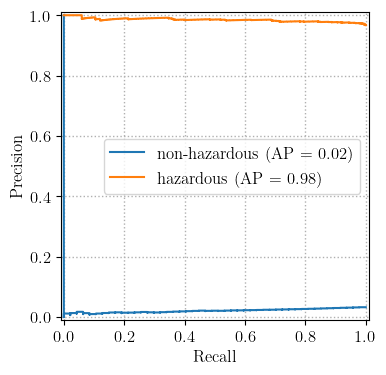

In [30]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(4,4))
# Precision Recall plot
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=0, name="non-hazardous", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=1, name="hazardous", ax=ax)
#ax.set_title("Precision recall curve for minority class")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="center right")
plt.savefig(Path.cwd() / "../report/pr_curve_min.eps", format="eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


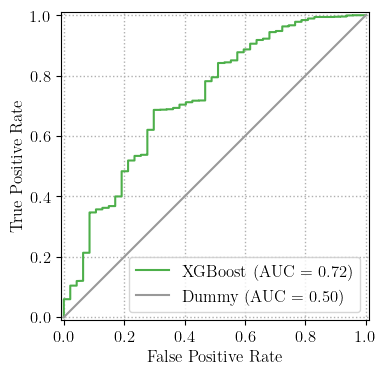

In [31]:
fig, ax = plt.subplots(figsize=(4,4))
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
RocCurveDisplay.from_predictions(y_test, test_probs[:, 1], name="XGBoost", ax=ax, plot_chance_level=False, curve_kwargs={"c":"#4daf4a"})
RocCurveDisplay.from_predictions(y_test, dummy_probs[:, 1], name="Dummy", ax=ax, curve_kwargs={"c":"#999999"})
ax.legend()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.savefig(Path.cwd() / "../report/roc_auc.eps", format="eps")

In [32]:
best_model = search.best_estimator_
best_idx = search.best_index_

fold_scores = [
    search.cv_results_[f"split{i}_test_score"][best_idx]
    for i in range(5)
]

print(fold_scores)
print(np.mean(fold_scores))

[np.float64(0.5871977944295207), np.float64(0.5903082143362081), np.float64(0.676551675385268), np.float64(0.6257498333703622), np.float64(0.6005380911922968)]
0.6160691217427312


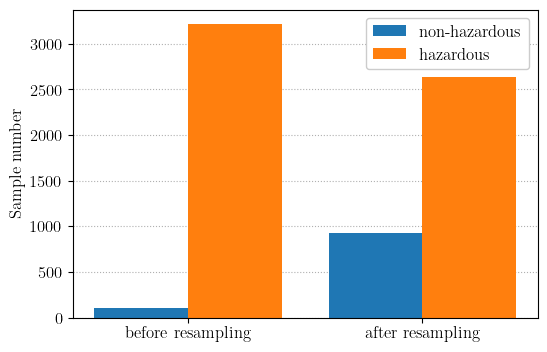

In [33]:
# SMOTE effect
before = Counter(y_exploration)
X_p = best_model.named_steps["pca"].fit_transform(X_exploration)
X_e, y_e = best_model.named_steps["smoteenn"].fit_resample(X_p, y_exploration)
after = Counter(y_e)

labels = sorted(before)
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(labels))
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(x-0.2, [before[0], after[0]], width=0.4, label="non-hazardous", zorder=2)
ax.bar(x+0.2, [before[1], after[1]], width=0.4, label="hazardous", zorder=2)
ax.set_xticks(x, ['before resampling', 'after resampling'])
ax.legend(loc="upper right", framealpha=1)
#ax.set_xlabel("Effect of SMOTE + ENN")
ax.set_ylabel("Sample number")
#ax.set_title("Sample amount before and after resampling")
plt.savefig(Path.cwd() / "../report/smote_effect.eps", format="eps")

In [34]:
print(before[0])
print(before[1])


print(after[0])
print(after[1])

109
3214
922
2633


In [35]:
print(np.mean(nested_scores))

0.5716247895067971


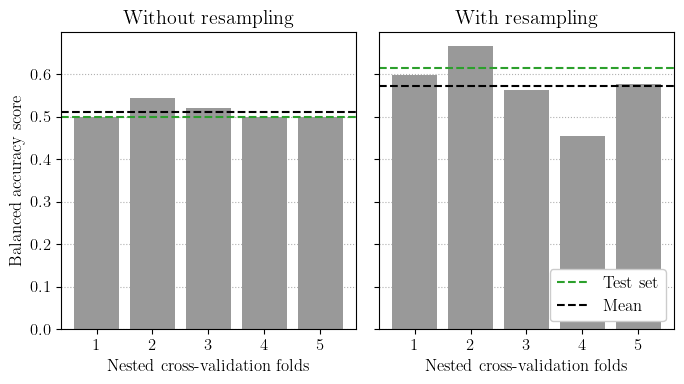

In [37]:
# CV Performance outer
fig, axes = plt.subplots(1, 2, figsize=(7,4), sharey=True)
ax = axes[1]
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(range(5), nested_scores, color="#999999", zorder=2)
ax.axhline(balanced_accuracy_score(y_test, test_preds), color="C2", ls="--", label="Test set")
ax.axhline(np.mean(nested_scores), color="black", ls="--", label="Mean")
ax.set_xticks(range(5))
ax.set_xticklabels(range(1, 6))
ax.set_title("With resampling")
ax.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

axe = axes[0]
axe.grid(axis="y", zorder=0, linestyle="dotted")
axe.bar(range(5), nr_nested_scores, color="#999999", zorder=2)
axe.axhline(balanced_accuracy_score(y_test, nr_test_preds), color="C2", ls="--", label="Test set")
axe.axhline(np.mean(nr_nested_scores), color="black", ls="--", label="Mean")
axe.set_title("Without resampling")
axe.set_ylabel("Balanced accuracy score")
axe.set_xticks(range(5))
axe.set_xticklabels(range(1, 6))
axe.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

#ax.set_title("5-fold cross validation performance")
plt.tight_layout()
plt.savefig(Path.cwd() / ".." / "report" / "cv_performance_outer.eps", format="eps")

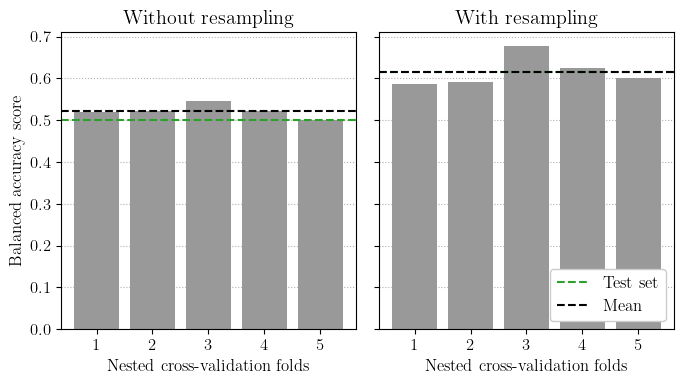

In [38]:
# CV performance inner
best_idx = search.best_index_
fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(5)]
nr_best_idx = nr_search.best_index_
nr_fold_scores = [nr_search.cv_results_[f"split{i}_test_score"][nr_best_idx] for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(7,4), sharey=True)
ax = axes[1]
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(range(5), fold_scores, color="#999999", zorder=2)
ax.axhline(balanced_accuracy_score(y_test, test_preds), color="C2", ls="--", label="Test set")
ax.axhline(np.mean(fold_scores), color="black", ls="--", label="Mean")
ax.set_xticks(range(5))
ax.set_xticklabels(range(1, 6))
ax.set_title("With resampling")
ax.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

axe = axes[0]
axe.grid(axis="y", zorder=0, linestyle="dotted")
axe.bar(range(5), nr_fold_scores, color="#999999", zorder=2)
axe.axhline(balanced_accuracy_score(y_test, nr_test_preds), color="C2", ls="--", label="Test set")
axe.axhline(np.mean(nr_fold_scores), color="black", ls="--", label="Mean")
axe.set_title("Without resampling")
axe.set_ylabel("Balanced accuracy score")
axe.set_xticks(range(5))
axe.set_xticklabels(range(1, 6))
axe.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

#ax.set_title("5-fold cross validation performance")
plt.tight_layout()
plt.savefig(Path.cwd() / ".." / "report" / "cv_performance_inner.eps", format="eps")

In [26]:
print(search)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('pca', PCA(random_state=0)),
                                       ('smoteenn', SMOTEENN(random_state=0)),
                                       ('clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=...
                                                      multi_strategy=None,
                                 

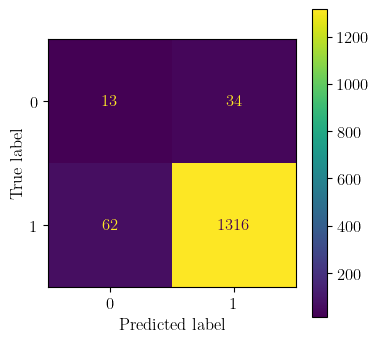

In [12]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_test.eps", format="eps")
plt.show()

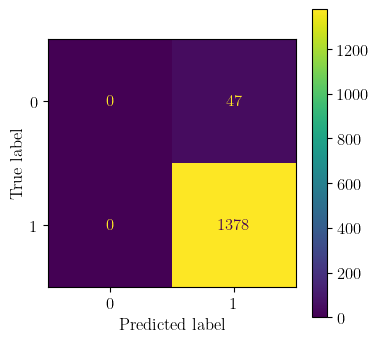

In [13]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, dummy_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_dummy.eps", format="eps")
plt.show()

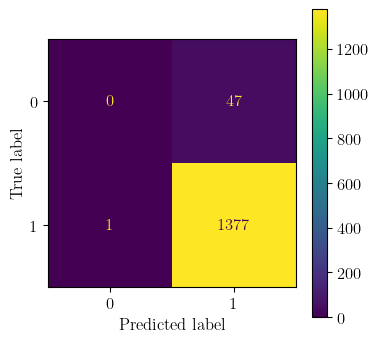

In [14]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, nr_test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_nr_test.eps", format="eps")
plt.show()

In [42]:
# Data preparation
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")

hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT',
        'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

# exclude NAs
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
plast_chem_hazard = plast_chem_hazard.where(plast_chem_hazard['Hazard_information_Toxicity_score'] != 0.25)

print(plast_chem_hazard['Hazard_information_Hazard_score'].value_counts())

# fingerprints
fps = calculate_mfps(plast_chem_hazard, 'Properties_isomeric_smiles')

mask = [fp is not None for fp in fps]
plast_chem_hazard = plast_chem_hazard[mask].copy()
fps = [fp for fp in fps if fp is not None]

X_fps = np.vstack(fps)

# include Properties into Data, not just fingerprints
prop_cols = ['Properties_molecular_weight', 'Properties_tpsa', 'Properties_complexity']
props = plast_chem_hazard[prop_cols].astype(float)

# NaNs mit mean interpoliert
props_scaled = StandardScaler().fit_transform(props.fillna(props.mean()))

X = np.hstack([X_fps, props_scaled]) 

print(X)

Hazard_information_Hazard_score
2.0    3049
0.5    1188
1.0    1041
0.0     161
Name: count, dtype: int64


[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] WARNING: not removing hydrogen atom without neighbors
[15:47:10] Explicit valen

[[ 0.          0.          0.         ... -0.52817419 -0.4741337
  -0.35921187]
 [ 0.          0.          0.         ... -0.51378725 -0.02963713
  -0.33760701]
 [ 0.          0.          0.         ... -0.33211119 -0.29735985
  -0.2463865 ]
 ...
 [ 0.          1.          0.         ... -0.36398099 -0.35628446
  -0.30159891]
 [ 0.          0.          0.         ... -0.59005624 -0.73417059
  -0.40962321]
 [ 0.          1.          0.         ...  0.86174971 -0.06038041
   0.58900137]]


In [45]:
# pca loadings plot
pca = best_model.named_steps["pca"]

feature_names = (
    [f"Morgan_{i}" for i in range(X_fps.shape[1])]
    + prop_cols
)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print(loadings)

                                  PC1       PC2       PC3       PC4       PC5  \
Morgan_0                     0.004558  0.001877  0.001899  0.000956 -0.008341   
Morgan_1                     0.019771  0.047126 -0.013474  0.118393 -0.065060   
Morgan_2                     0.002932 -0.005546  0.003494 -0.005351 -0.027073   
Morgan_3                     0.005171  0.011359 -0.005153 -0.002532  0.008481   
Morgan_4                     0.008952  0.000552 -0.006668 -0.002547  0.001459   
...                               ...       ...       ...       ...       ...   
Morgan_2046                  0.008349 -0.000247  0.003242 -0.002066 -0.005393   
Morgan_2047                  0.010614  0.000601 -0.005773  0.002829 -0.016412   
Properties_molecular_weight  0.474404  0.074877  0.148152 -0.174584 -0.237040   
Properties_tpsa              0.432596 -0.072626  0.403763  0.003609  0.313975   
Properties_complexity        0.492702 -0.043282  0.009424 -0.019571 -0.296849   

                           

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


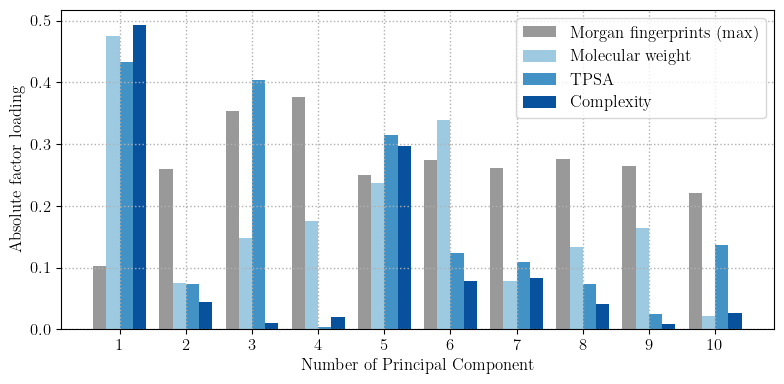

In [90]:

morgan_cols = [f"Morgan_{i}" for i in range(2048)]
loadings = loadings.iloc[:, :30]
morgan_max = loadings.abs().loc[morgan_cols].max(axis=0)

property_loadings = loadings.abs().loc[prop_cols]

plt.figure(figsize=(8, 4))
plt.grid(zorder=0,linestyle='dotted', linewidth=1)
width = 0.2
x = np.arange(len(np.arange(1,11)))

colors = [
    "#999999",    # Morgan FPs
    "#9ecae1",    # molecular weight
    "#4292c6",    # tpsa
    "#08519c"     # complexity
]

plt.bar(
    x - 1.5 * width,
    morgan_max.iloc[:10],
    width,
    label="Morgan fingerprints (max)",
    color=colors[0]
)

plt.bar(
    x - 0.5 * width,
    property_loadings.loc["Properties_molecular_weight"].iloc[:10],
    width,
    label="Molecular weight",
    color=colors[1]
)

plt.bar(
    x + 0.5 * width,
    property_loadings.loc["Properties_tpsa"].iloc[:10],
    width,
    label="TPSA",
    color=colors[2]
)

plt.bar(
    x + 1.5 * width,
    property_loadings.loc["Properties_complexity"].iloc[:10],
    width,
    label="Complexity",
    color=colors[3]
)

plt.xticks(x,[i for i in range(1, 11)])

plt.xlabel("Number of Principal Component")
plt.ylabel("Absolute factor loading")
#plt.title("Strongest factor loadings Morgan fingerprints vs physicochemical properties")
plt.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "../report/pca_afl.eps", format="eps")

### Values for Text

In [15]:
print(balanced_accuracy_score(y_test, test_preds))
print(classification_report(y_test, test_preds))
print(roc_auc_score(y_test, test_probs[:, 1]))

0.6158015007874502
              precision    recall  f1-score   support

         0.0       0.17      0.28      0.21        47
         1.0       0.97      0.96      0.96      1378

    accuracy                           0.93      1425
   macro avg       0.57      0.62      0.59      1425
weighted avg       0.95      0.93      0.94      1425

0.7233965352190964


In [16]:
47 + 1378

1425

In [17]:
print(search.best_params_)
print(search.best_score_)

{'clf__colsample_bylevel': 1.0, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__n_estimators': 300, 'pca__n_components': 160, 'smoteenn__sampling_strategy': 0.3}
0.6160691217427312


In [18]:
len(search.cv_results_["params"])

729

In [19]:
len(X_exploration[y_exploration==1])

3214

In [20]:
len(X_test)

1425

In [21]:
len(X_test[y_test==0.0])

47

In [25]:
pca = best_model.named_steps["pca"]
print(pca.explained_variance_ratio_.sum())
print(pca.n_components)

0.5921566149534921
160


In [115]:
print(nested_scores)

[0.59808426 0.66566521 0.56273858 0.45382508 0.57781082]
